# Data Analysis 5: Curve Fitting - Continued 

Fitting a function (or 'curve') to data is hugely important within both scientific and data-analytic fields. 
 
## Contents 
In this `data_analysis_5` notebook we focus on :
1. Curve Fitting using the `np.polynomial.Polynomial.fit` function previously introduced in the notebook [data_analysis_4.ipynb](data_analysis_4.ipynb)

NB: There are lots of online documents refering to `numpy.poly` and `numpy.polyfit`. There is nothing wrong with using these functions but you should be aware that, 
 - These functions are regarded as old/legacy, and that it is a good idea to use the more recent code, `np.polynomial.Polynomial` or `np.polynomial.Polynomial.fit`
 - The older functions do NOT have exactly the same syntax as the new functions (see [https://numpy.org/doc/stable/reference/routines.polynomials.html](https://numpy.org/doc/stable/reference/routines.polynomials.html) for more details)

In [2]:
# Imports ...
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


# 1. Synthesizing Data

It will be useful for us to have some data to which we can later try to fit some data. 

In the cell below we define a function that allows us to generate points that lie on a polynomial curve.

The function allows us to specify 
    
    n_points: int
     - number of points to be made 
     
    coefficients: list (of floats)
     - the coefficients of the polynomial
     - NB: coefficients go from degree zero upward: https://numpy.org/doc/stable/reference/routines.polynomials.html
     - E.g with the coeffs = [1,2,3] we are specifying 1 +2x + 3x^2 
 
    add_random_noise: boolean
     - whether or not we want to add noise to the data 
     
    sigma: float
     - if we are adding noise, what standard-deviation do we want to use for the distribution of noise/uncertainty


In [3]:
def create_data(n_points = 4 , coefficients = [1,2,3], add_random_noise = False, sigma = 2.0 ):
    """
    Convenience function to create some synthetic data 

    optional arguments 
    ------------------
    
    n_points: int
     - number of points to be made 
     
    coefficients: list (of floats)
     - the coefficients of the polynomial
     - NB: coefficients go from degree zero upward: https://numpy.org/doc/stable/reference/routines.polynomials.html
     - E.g with the coeffs = [1,2,3] we are specifying 1 +2x + 3x^2 
     
    add_random_noise: boolean
     - whether or not we want to add noise to the data 
     
    sigma: float
     - if we are adding noise, what standard-deviation do we want to use for the distribution of noise/uncertainty
    
   
    
    returns 
    ------------------
    x_values: 
    y_values: 
    """
    # Use the numpy.poly1d class to constuct a handy representation of a polynomial
    # NB: coefficients go from degree zero upward: https://numpy.org/doc/stable/reference/routines.polynomials.html
    # E.g with the coeffs = [1,2,3] we are specifying 1 +2x + 3x^2 
    p = np.polynomial.Polynomial(coefficients)
    
    # Choose some x-values at which we will evaluate the function 
    x_values = np.random.default_rng().uniform(0,5,n_points)
    
    # Evaluate the y-values at the chosen x-values
    y_values = p(x_values)
    
    # If desired, add some random "errors"/"noise"
    if add_random_noise:
        mu=0
        y_random = np.random.default_rng().normal(mu, sigma, n_points)
        y_values = y_values + y_random
    
    return x_values, y_values

We now generate some points which lie along a polynomial with 4 coefficients (3rd degree) ...

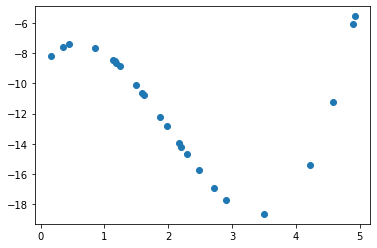

In [4]:
# create some data for which the underlying data is a 3rd-degree polynomial
# - NB Remember that 4 coeffients means the highest power is $x^3$, hence this is 3rd-degree
x_a, y_a = create_data(coefficients = [-9,6,-6,1], add_random_noise = False, n_points = 24)

# plot the data we generated 
plt.scatter(x_a, y_a)

# 2. Data Fitting using np.polynomial.Polynomial.fit

# 2.1 *Degree* of the Assumed Fit

 - We start by fitting some polynomials to the data `x_a, y_a` 
 - This data was generated (above) using a *third-degree* polynomial.

### Using the *wrong* polynomial 
In the first cell below we illustrate what happens if we try to fit a polynomial of the ***wrong*** degree:
 - We tell the fit routine to assume a *second-degree* polynomial rather than a *third* degree polynomial
 - We see that ethe fitted coefficients are *not* the same as input when creating the data
 - This is to be expected: we are forcing the fit routine to use the wrong model, so it can't get to exactly the right answer

returned (scaled) component values:  -14.69208212 - 2.38128532·x + 8.40871886·x²
actual fitted components: -2.60375789 - 8.52010665·x + 1.48063805·x²


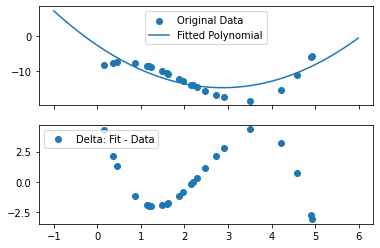

In [5]:
# return the best fit polynomial of deg 2
# NB: This is 1-degree lower than the polynomial used to construct the data
p_fitted = np.polynomial.Polynomial.fit(x_a, y_a, deg=2)

# note that the returned fit-object's values are NOT the polynomial components you expect! 
# - to get those you have to use `convert()` 
# - See https://numpy.org/doc/stable/reference/routines.polynomials.html
print('returned (scaled) component values: ', p_fitted)
print('actual fitted components:', p_fitted.convert())


# Set up a 2-panel plot ... 
fig, axs = plt.subplots(2, sharex=True)

# plot[0]: Absolute values ...
# - (i) the original data we generated (using the 3rd-degree polynomial) 
axs[0].scatter(x_a, y_a , label='Original Data')

# - (ii)plot the best-fit 2nd-degree polynomial over a range of x-values 
x=np.arange(-1,6,0.01)
axs[0].plot(x, p_fitted(x),   label='Fitted Polynomial' )
axs[0].legend()

# plot[1]: Difference between data and the fit ...
_ = axs[1].scatter(x_a, p_fitted(x_a) - y_a , label='Delta: Fit - Data')
axs[1].legend()

### And now we fit a polynomial of the correct degree:
 - We see that the returned coefficients are the same as input

returned (scaled) values:  -16.08119052 - 12.21583971·x + 9.19569956·x² + 13.53385092·x³
actual fitted components: -9.0 + 6.0·x - 6.0·x² + 1.0·x³


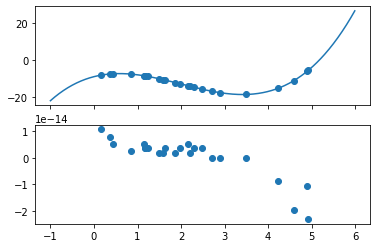

In [6]:
# return the best fit polynomial of deg=3
# NB: This is the SAME degree as the polynomial used to construct the data
p_fitted = np.polynomial.Polynomial.fit(x_a, y_a, deg=3)

# note that the returned fit-object's values are NOT the polynomial components you expect! 
# - to get those you have to use `convert()` 
# - See https://numpy.org/doc/stable/reference/routines.polynomials.html
print('returned (scaled) values: ', p_fitted)
print('actual fitted components:', p_fitted.convert())


# Set up a 2-panel plot ... 
fig, axs = plt.subplots(2, sharex=True)

# plot[0]: Absolute values ...
# - (i) the original data we generated using the 4th-order polynomial 
axs[0].scatter(x_a, y_a , label='Original Data')

# - (ii)plot the best-fit 3rd-order polynomial over a range of x-values 
x=np.arange(-1,6,0.01)
axs[0].plot(x, p_fitted(x),   label='Fitted Polynomial' )

# plot[1]: Difference between data and the fit ...
_ = axs[1].scatter(x_a, p_fitted(x_a) - y_a , label='Delta: Fit - Data')


### We now  fit a polynomial to some data `x_b, y_b` that we generate using a third-degree polynomial plus the addition of some *errors*
 - We will use a third-degree polynomial for the fit (i.e. the same as used to generate the data). 
 - We will see that the fitted coefficients are *not* the same as the input coefficients, even though the assumed degree of the polynomial is correct
 - That is because the "errors"/"noise" in the data prevent the exact parameters from being recovered
 

### Generate the data ...

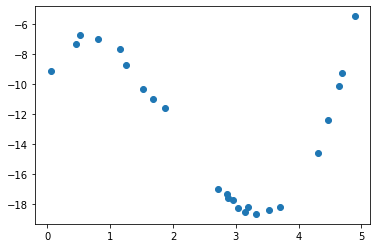

In [7]:
# create some data for which the underlying data is a 3rd-order polynomial
# - This time we add-in some "errors" around the values.
# - This has the effect of moving the data points away from the precise polynomial curve
coefficients = [-9,6,-6,1]
x_b, y_b = create_data(coefficients = coefficients, add_random_noise = True, n_points = 24, sigma=0.5)

# plot the data we generated using the 3rd-order polynomial 
plt.scatter(x_b, y_b)


### Fit the data ...

returned (scaled) values: -15.55080669 - 13.63371081·x + 8.38590597·x² + 15.31178645·x³
actual fitted components: -9.16889614 + 7.0335644·x - 6.54572737·x² + 1.07473738·x³
input coefficients......: [-9, 6, -6, 1]


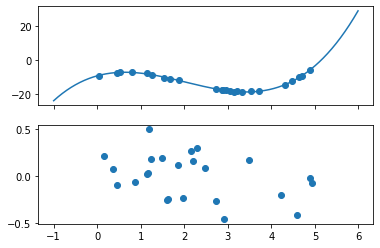

In [8]:
# return the best fit polynomial of deg 3
p_fitted = np.polynomial.Polynomial.fit(x_b, y_b, deg=3)

# note that the returned fit-object's values are NOT the polynomial components you expect! 
# - to get those you have to use `convert()` 
# - See https://numpy.org/doc/stable/reference/routines.polynomials.html
print('returned (scaled) values:', p_fitted)
print('actual fitted components:', p_fitted.convert())
print('input coefficients......:', coefficients)

# Set up a 2-panel plot ... 
fig, axs = plt.subplots(2, sharex=True)

# plot[0]: Absolute values ...
# - (i) the original data we generated using the 3rd-order polynomial 
axs[0].scatter(x_b, y_b , label='Original Data')

# - (ii)plot the best-fit 3rd-order polynomial over a range of x-values 
x=np.arange(-1,6,0.01)
axs[0].plot(x, p_fitted(x),   label='Fitted Polynomial' )

# plot[1]: Difference between data and the fit ...
_ = axs[1].scatter(x_a, p_fitted(x_b) - y_b , label='Delta: Fit - Data')


# Exercise 5 (A)
1. Create a function, `create_and_fit` with an argument `coefficients`. 
 - The function should...
   - call the above `create_data` and `np.polynomial.Polynomial.fit` functions 
   - pass the `coefficients` arguments into the `create_data` function 
   - use the `add_random_noise = True` option for `create_data`.
   - ensure the degree is correct by setting `deg = len(coefficients)-1`
   - use the `.convert` function to convert the results of the fit
   - use the `.coef` attribute (see https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.fit.html ) to extract just the fitted coefficients (rather than the polynomial )
   - return the  coefficents 
   
2. Call your `create_and_fit` function with `coefficients = [3,2,1]`
 - How close are the fitted coefficients to your input coefficients? 
 
3. Now repeatedly (e.g. 10,000 times) call your `create_and_fit` function
 - Each time you call `create_and_fit`,
   - Keep the coefficients the same for all calls to `create_data`. 
   - Keep the optional arguments, `n_points` and `sigma` the same in all calls to `create_data`
   - Keep the degree (`deg`) the same in all calls to `fit`.
   - Collect the fitted coefficients into a list or array
4. Make a plot comparing ...
 - the original input value for the [0] & [1] component of the coefficients, 
 - the individual values for the fits for the [0] & [1] component of the coefficients, 
 - the mean value for the fits for the [0] & [1] component of the coefficients, and 
5. What do you notice about the average of the fitted coefficients?
